In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [17]:
X, y =load_breast_cancer(return_X_y=True) # এভাবে দিলে X, y আকারে দিবে
print('Feature matrix shape:', X.shape)
print('Target vector shape:', y.shape)

Feature matrix shape: (569, 30)
Target vector shape: (569,)


In [18]:
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.25, random_state=42)

In [19]:
# Baseline Model: Dcision Stump
stump= DecisionTreeClassifier(max_depth=1, random_state=42)
stump.fit(X_train, y_train)

y_pred_stump= stump.predict(X_test)
print('Accuracy: ',accuracy_score(y_test, y_pred_stump))
print(classification_report(y_test, y_pred_stump))

Accuracy:  0.8951048951048951
              precision    recall  f1-score   support

           0       0.82      0.93      0.87        54
           1       0.95      0.88      0.91        89

    accuracy                           0.90       143
   macro avg       0.89      0.90      0.89       143
weighted avg       0.90      0.90      0.90       143



In [20]:
# building AdaBoost Model
base_learner= DecisionTreeClassifier(max_depth=1, random_state=42) # এই DecisionTreeClassifier দিয়ে আমরা adaboost model বানাব, আমরা চাইলে অন্য model দিয়েও বানাইতে পারি

ada= AdaBoostClassifier(
    estimator=base_learner,
    n_estimators=20,
    learning_rate=0.1,
    random_state=42
)

ada.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=42),
                   learning_rate=0.1, n_estimators=20, random_state=42)

In [21]:
y_pred_ada= ada.predict(X_test)

print('Accuracy: ', accuracy_score(y_test, y_pred_ada))
print(classification_report(y_test, y_pred_ada))

Accuracy:  0.965034965034965
              precision    recall  f1-score   support

           0       0.96      0.94      0.95        54
           1       0.97      0.98      0.97        89

    accuracy                           0.97       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143



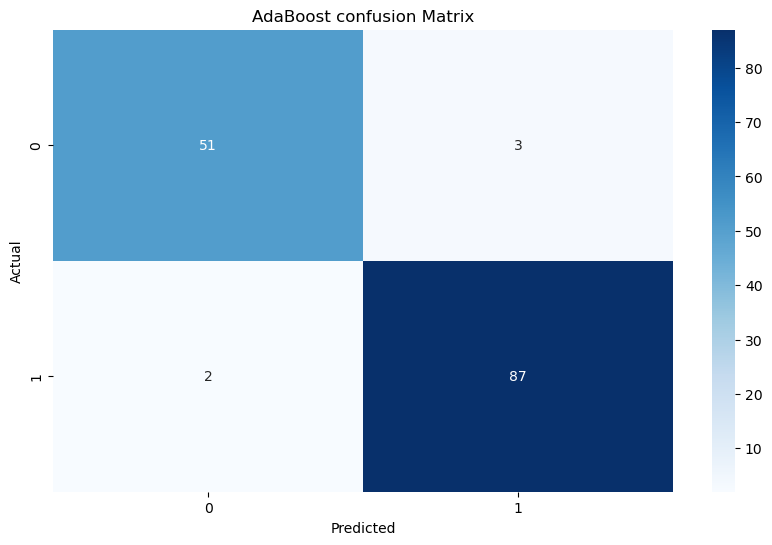

In [22]:
cm= confusion_matrix(y_test, y_pred_ada)

plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('AdaBoost confusion Matrix')
plt.show()

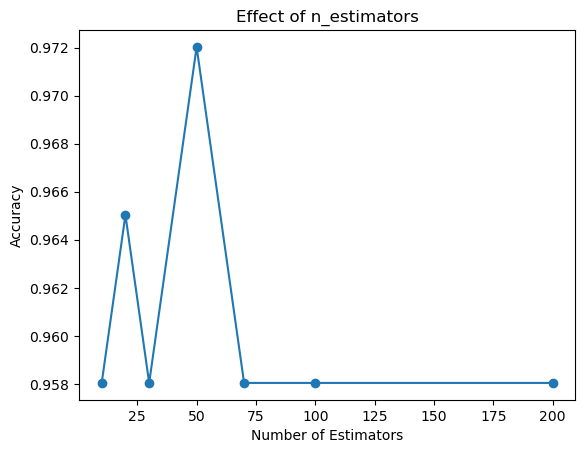

In [25]:
# effect of number of estimators
estimators= [10, 20, 30, 50, 70, 100, 200]
accs= []

for n in estimators:
    model= AdaBoostClassifier(
        estimator=base_learner,
        n_estimators=n,
        learning_rate=0.3,
        random_state=42
    )
    model.fit(X_train, y_train)
    pred=model.predict(X_test)
    accs.append(accuracy_score(y_test, pred))


plt.plot(estimators, accs, marker='o')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title('Effect of n_estimators')
plt.show()

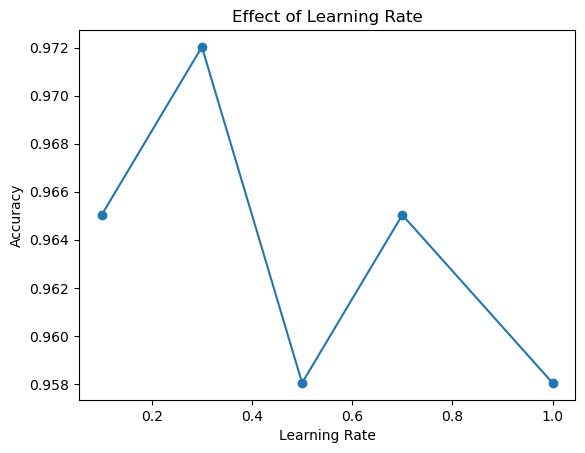

In [26]:
#Effect of Learning Rate
rates = [0.1, 0.3, 0.5, 0.7, 1.0]
accs_lr = []

for lr in rates:
  model = AdaBoostClassifier(
      estimator = base_learner,
      n_estimators = 50,
      learning_rate = lr,
      random_state = 42
  )
  model.fit(X_train,y_train)
  accs_lr.append(accuracy_score(y_test,model.predict(X_test)))


plt.plot(rates, accs_lr, marker='o')
plt.xlabel('Learning Rate')
plt.ylabel('Accuracy')
plt.title('Effect of Learning Rate')
plt.show()

In [28]:
# GridSearchCV
param_grid = {
    'n_estimators': [20, 50, 100, 200],
    'learning_rate': [0.1, 0.3, 0.5, 0.7, 1.0],
    'estimator__max_depth': [1, 2]
}

grid= GridSearchCV(
    estimator=AdaBoostClassifier(
        estimator=base_learner,
        random_state=42
    ),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)
best_model= grid.best_estimator_
y_pred_grid= best_model.predict(X_test)

print('Best Parameters :')
print(grid.best_params_)
print('Test Accuracy (GridSearch AdaBoost): ',accuracy_score(y_test, y_pred_grid))
print(classification_report(y_test, y_pred_grid))

Best Parameters :
{'estimator__max_depth': 1, 'learning_rate': 1.0, 'n_estimators': 200}
Test Accuracy (GridSearch AdaBoost):  0.9790209790209791
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        54
           1       0.99      0.98      0.98        89

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143

